# 다양한 분류 알고리즘

## 로지스틱 회귀

### 럭키백의 확률

- 럭키백에 들어갈 수 있는 생선은 7개

- 럭키백에 들어간 생선의 크기, 무게 등이 주어졌을 때 7개 생선에 대한 확률을 출력

- k-최근접 이웃은 주변 이웃을 찾아주니 이웃의 클래스 비율을 확률이라고 출력하면 되지 않을까?

- 사이킷런의 k-최근접 이웃 분류기도 이와 동일한 방식으로 클래스 확률을 계산하여 제공

#### 데이터 준비하기

In [1]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
# 어떤 종류의 생선이 있는지 고유한 값 추출
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [3]:
# species 열을 타깃으로 만들고 나머지 5개 열은 입력 데이터로 사용
# 데이터프레임에서 원하는 열을 리스트로 나열
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Weight']].to_numpy()

- 데이터프레임에서 여러 열을 선택하면 새로운 데이터프레임이 변환됨
- 이를 to_numpy() 메서드로 넘파이 배열로 바꾸어 저장함

In [5]:
# 처음 5개 행 출력
print(fish_input[:5])

[[242.      25.4     30.      11.52   242.    ]
 [290.      26.3     31.2     12.48   290.    ]
 [340.      26.5     31.1     12.3778 340.    ]
 [363.      29.      33.5     12.73   363.    ]
 [430.      29.      34.      12.444  430.    ]]


In [6]:
# 타깃 데이터
fish_target = fish['Species'].to_numpy()

In [7]:
# 세트 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

In [8]:
# 표준화 전처리
# 훈련 세트의 통계 값으로 테스트 세트를 변환해야 함
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### k-최근접 이웃 분류기의 확률 예측

In [9]:
#KNeighborsClassifier 클래스 객체를 만들고 훈련 세트로 모델 훈련
# 훈련 세트와 테스트 세트의 점수 확인
# k를 3으로 지정
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


- 다중 분류(multi-class classification)

- 타깃 데이터에 2개 이상의 클래스가 포함된 문제

- 이진 분류를 사용했을 때는 양성 클래스와 음성 클래스를 각각 1과 0으로 지정하여 타깃 데이터를 만들었다

- 다중 분류에서도 타깃값을 숫자로 바꾸어 입력할 수 있지만 사이킷런에서는 문자열로 된 타깃값을 그대로 사용할 수 있음

- 타깃값을 그대로 사이킷런 모델에 전달하면 순서가 자동으로 알파벳 순으로 매겨짐

- pd.unique(fish['Species'])로 출력했던 순서와 다름
- KNeighborsClassifier에서 정렬된 타깃값을 classes_ 속성에 저장됨

In [10]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [11]:
# 처음 5개 샘플의 타깃값 예측
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


- 사이킷런의 분류 모델은 predict_proba() 메서드로 클래스별 확률값을 반환

- 넘파이 round() 함수는 기본으로 소숫점 첫째 자리에서 반올림
- decimals 매개변수로 유지할 소수점 아래 자릿수를 지정 가능

In [12]:
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4)) # 소숫점 네 번째 자리까지 표기 -> 다섯 번째 자리에서 반올림

[[0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.3333 0.     0.6667 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


- predict_proba() 메서드의 출력 순서는 classes_ 속성과 같음

- 첫 번째 열이 'Bream'에 대한 확률, 두 번째 열이 'Parkki'에 대한 확률

In [13]:
# 4번째 샘플의 최근접 이웃의 클래스 확인
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[['Roach' 'Perch' 'Roach']]


### 로지스틱 회귀

- 로지스틱 회귀(logistic regression)

- 이름은 회귀이지만 분류 모델
- 선형 회귀와 동알하게 선형 방정식을 ㅎ가습함

- 시드모이드 함수(sigmoid function)(또는 로지스틱 함수(logistic function)을 사용하면 z가 큰 음수일 때 0이 되고, 큰 양수일 때 1이 되도록 바꿀 수. ㅣㅆ음

- 시그모이드 함수

- 선형 방적식의 출력 z의 음수를 사용해 자연 상수 e를 거듭제곱하고 1을 더한 값의 역수를 취함
- z가 무한하게 큰 음수일 경우 이 함수는 0에 가까워지고
- z가 무한하게 큰 양수가 될 때는 1에 가까워짐
- z가 어떤 값이 되더라고 절대 0~1 사이의 범위를 벗어날 수. ㅓㅂㅅ음

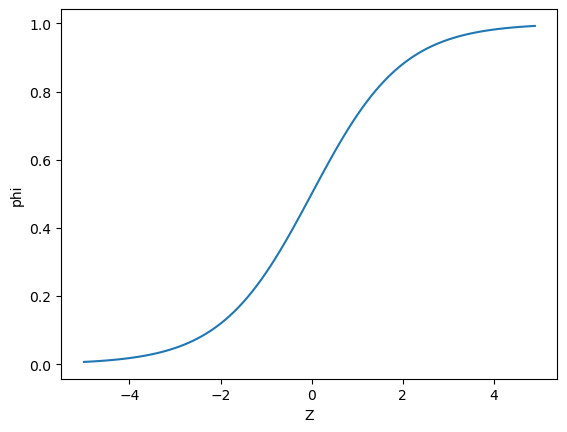

In [14]:
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('Z')
plt.ylabel('phi')
plt.show()

- 시그모이드 함수의 출력은 0에서 1까지 변함

- 사이킷런에는 로지스틱 회귀 모델인 LogistixRegression 클래스 존재

- 이진 분류일 경우 시그모이드 함수의 출력이 0.5보다 크면 양성 클래스

- 0.5보다 작으면 음성 클래스로 판단

#### 로지스틱 회귀로 이진 분류 수행하기

- 넘파이 배열은 True, False 값을 전달하여 행을 선택할 수 있음

- 이를 불리언 인덱싱(boolean indexing)이라 함

In [15]:
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [17]:
# 훈련 세트에서 도미와 빙어 행만 골라내기
# 비교 연산자를 사용하면 도미와 빙어의 행을 모두 T로 만들 수 있음
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_Smelt = train_target[bream_smelt_indexes]

- bream_smelt_indexes 배열은 도미와 빙어일 경우 True, 그 외는 모두 False

- 이 배열을 사용해 train_scaled와 train_target 배열에 불리언 인덱싱을 적용하면 도미와 빙어 데이터만 골라낼 수. ㅣㅆ음

In [18]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_Smelt)

LogisticRegression()

In [20]:
# 훈련한 모델을 사용해 train_bream_smelt에 있는 처음 5개 샘플 예측
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [21]:
# train_bream_smelt에서 처음 5개 샘플의 예측 확률 출력
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99736811 0.00263189]
 [0.03437866 0.96562134]
 [0.9953072  0.0046928 ]
 [0.98639807 0.01360193]
 [0.99773108 0.00226892]]


In [22]:
print(lr.classes_)

['Bream' 'Smelt']


- 빙어가 양성

- 나머지는 도미

In [23]:
# 로지스틱 회귀가 학습한 계수 확인
print(lr.coef_, lr.intercept_)

[[-0.45064225 -0.65434866 -0.7519052  -1.14503148 -0.45064225]] [-1.97986974]


In [24]:
# train_bream_smelt의 처음 5개 샘플의 z값 출력
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-5.93741692  3.3353358  -5.35702191 -4.28384799 -6.08617825]


- 이 z 값을 시그모이드 함수에 통과시키면 확률을 얻을 수 있음

- 파이써느이 사이파이 라이브러리의 시그모이드 함수 -> expit()
- np.exp() 함수를 사용해 분수 계산을 하는 것보다 편리, 안전

In [26]:
# decision 배열의 값을 확률로 변환
from scipy.special import expit
print(expit(decisions))

[0.00263189 0.96562134 0.0046928  0.01360193 0.00226892]


- decision_function() 메서드는 양성 클래스에 대한 z 값을 반환

#### 로지스틱 회귀로 다중 분류 수행하기

- LogisticRegression 클래스는 기본적으로 반복적인 알고리즘 사용

- max_iter 매개변수에서 반복 횟수를 지정하며 기본값은 100
- 여기에 준비한 데이터셋을 사용해 모델을 훈련하면 반복 횟수가 부족하다는 경고 발생

- LogisticRegression은 기본적으로 릿지 회귀로 같이 계수의 제곱을 규제

- 이런 규제를 L2규제라고도 부름
- 릿지 회귀에서는 alpha 매개변수로 규제의 양을 조절
- alpha가 커지면 규제도 커짐
- LogisticRegression에서 규제를 제어하는 배개변수는 C
- C는 alpha와 반대로 작을수록 규제가 커짐
- C의 기본값을 1


In [27]:
# 다중 분류 모델 훈련
lr = LogisticRegression(C = 20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9495798319327731
0.925


In [28]:
# 처음 5개 샘플에 대한 예측
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [29]:
# 예측 확률 출력
# 소수점 네 번째 자리에서 반올림
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.028 0.802 0.    0.143 0.023 0.004]
 [0.    0.001 0.207 0.    0.017 0.775 0.   ]
 [0.    0.    0.174 0.777 0.047 0.001 0.   ]
 [0.009 0.032 0.401 0.002 0.472 0.    0.084]
 [0.    0.001 0.865 0.002 0.12  0.01  0.003]]


In [30]:
# 클래스 정보 확인
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


- 이진 분류는 샘플마다 2개의 확률을 출력

- 다중 분류는 샘플마다 클래스의 개수만큼 확률을 출력
- 이 중에서 가장 높은 확률이 예측 클래스가 됨

In [31]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


- coef_ 배열의 열 5개, 행 7개
- intercept_ 7개

- 이진 분류에서 보았던 z를 7개 개산한다는 뜻

- 다중 분류는 클래스마다 z 값을 하나씩 계산

- 가장 높은 z 값을 출력하는 클래스가 예측 클래스가 됨
- 이진 분류에서는 시그모이드 함수를 사용해 z를 0과 1 사이의 값으로 변환
- 다중 분류는 이와 달리 소프트맥스(softmax) 함수를 사용하여 7개의 z 값을 확률로 변환

- 소프트맥스 함수

- 여러 개의 선형 방정식의 출력값을 0~1 사이로 압축하고 전체 합이 1이 되도록 만든다
- 이를 위해 지수 함수를 사용하기 때문에 '정규화된 지수 함수'라고 부름